In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os 
import glob
import json     

In [2]:
import pandas as pd, glob

for file in glob.glob('*.json'):
    df = pd.read_json(file, lines=True)
df = df.sort_values(by='timestamp', ascending=True)
df.head()

,id,device_id,device_name,timestamp,measurement_time_utc,date,data,processed_timestamp,annotations
0,1299333926,28:37:2F:FF:E7:68,AmbyteOnAir,2001-01-01 00:01:59+00:00,2001-01-01T00:01:59.000Z,2001-01-01,"[{'data': {'env': [22.42], 'leaf': [140, 343, ...",2026-06-09T12:45:56.756Z,[]
1,1344848666,28:37:2F:FF:E7:68,AmbyteOnAir,2001-01-01 00:02:00+00:00,2001-01-01T00:02:00.000Z,2001-01-01,"[{'data': {'env': [22.08], 'leaf': [144, 342, ...",2026-06-09T12:45:56.756Z,[]
2,1599866163,28:37:2F:FF:E7:68,AmbyteOnAir,2001-01-01 00:02:00+00:00,2001-01-01T00:02:00.000Z,2001-01-01,"[{'data': {'env': [21.99], 'leaf': [878, 656, ...",2026-06-09T12:45:56.756Z,[]
3,186516016,28:37:2F:FF:E7:68,AmbyteOnAir,2001-01-01 00:02:00+00:00,2001-01-01T00:02:00.000Z,2001-01-01,"[{'data': {'env': [21.87], 'leaf': [41, 287, 2...",2026-06-09T12:45:56.756Z,[]
4,1459088716,28:37:2F:FF:E7:68,AmbyteOnAir,2001-01-01 00:02:00+00:00,2001-01-01T00:02:00.000Z,2001-01-01,"[{'data': {'env': [22.35], 'leaf': [357, 361, ...",2026-06-09T12:45:56.756Z,[]


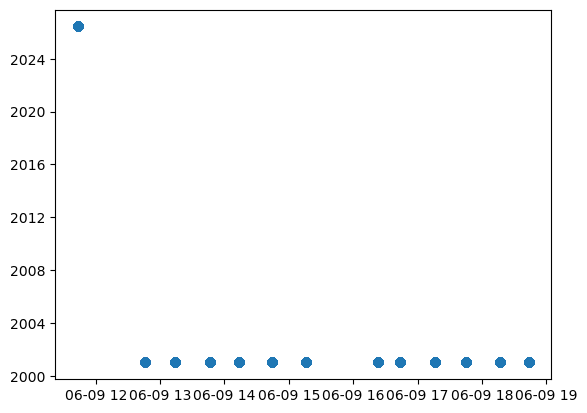

In [22]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df["processed_timestamp"] = pd.to_datetime(df["processed_timestamp"])

tdf = df[df["processed_timestamp"] > "2026-06-09 11:00:00"]
plt.scatter(tdf["processed_timestamp"], tdf["timestamp"])

In [3]:
results = []
for row in df.itertuples():
    data = row.data
    try:
        data[0]["metadata"]["segments"]
    except Exception as e:
        info = data[0]["data"]
        # print(info)
        if "battery_v" in info.keys():
            results.append(row)

df_bat= pd.DataFrame(results)
inner = pd.json_normalize(df_bat['data'].str[0])   # -> data.battery_v, sensor, measure_id, ...
inner.index = df_bat.index
df_bat = pd.concat([df_bat.drop(columns='data'), inner], axis=1)
df_bat.head()

,Index,id,device_id,device_name,timestamp,measurement_time_utc,date,processed_timestamp,annotations,device,...,data.charge_ma,data.charge_status,data.db_online,data.input_ma,data.input_present,data.input_v,data.provisioned,data.publish_gate,data.system_v,data.wifi
0,182,441751963,28:37:2F:FF:E7:68,AmbyteOnAir,2001-01-01 00:05:02+00:00,2001-01-01T00:05:02.000Z,2001-01-01,2026-06-09T12:45:56.756Z,[],None,...,0,0,True,239,True,5.04,True,True,4.04,True
1,183,99762516,28:37:2F:FF:E7:68,AmbyteOnAir,2001-01-01 00:05:03+00:00,2001-01-01T00:05:03.000Z,2001-01-01,2026-06-09T13:14:14.576Z,[],None,...,490,2,True,532,True,6.84,True,True,3.98,True
2,312,1391434272,28:37:2F:FF:E7:68,AmbyteOnAir,2001-01-01 00:10:03+00:00,2001-01-01T00:10:03.000Z,2001-01-01,2026-06-09T13:14:14.576Z,[],None,...,542,2,True,518,True,7.02,True,True,3.98,True
3,421,802135888,28:37:2F:FF:E7:68,AmbyteOnAir,2001-01-01 00:15:03+00:00,2001-01-01T00:15:03.000Z,2001-01-01,2026-06-09T13:46:50.166Z,[],None,...,0,2,True,292,True,4.26,True,True,3.94,True
4,534,1727143778,28:37:2F:FF:E7:68,AmbyteOnAir,2001-01-01 00:20:03+00:00,2001-01-01T00:20:03.000Z,2001-01-01,2026-06-09T13:46:50.166Z,[],None,...,0,2,True,279,True,4.20,True,True,3.94,True


<Axes: xlabel='Index'>

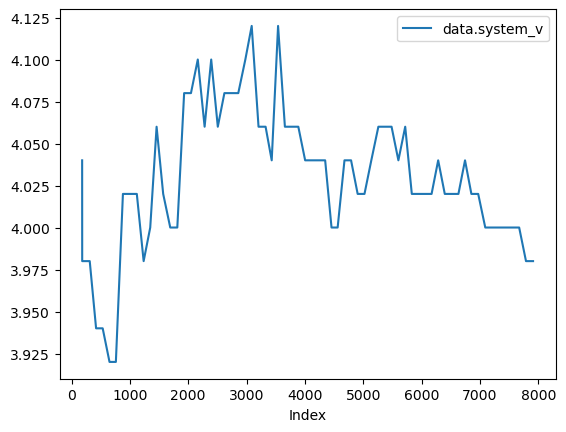

In [73]:
df_bat.plot(x="Index", y="data.system_v")

<Axes: xlabel='Index'>

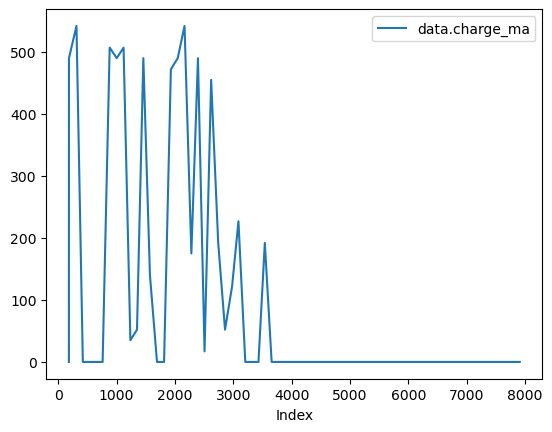

In [71]:
df_bat.plot(x="Index", y="data.charge_ma")

<Axes: xlabel='Index'>

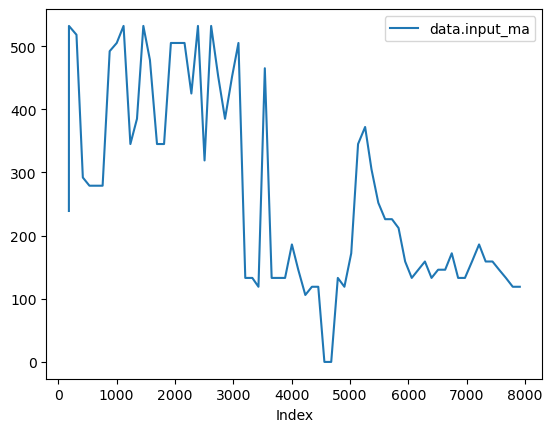

In [72]:
df_bat.plot(x="Index", y="data.input_ma")

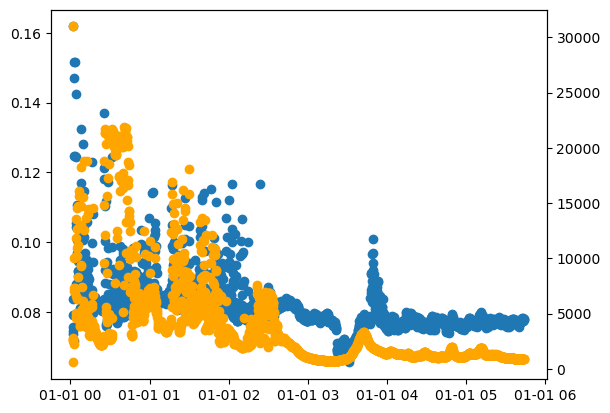

In [33]:
results = []
for row in df.itertuples():
    data = row.data[0]
    if data["sensor"]=="AMBIT_1":
        results.append(row)

dfamb = pd.DataFrame(results)
inner = pd.json_normalize(dfamb['data'].str[0])   # -> data.battery_v, sensor, measure_id, ...
inner.index = dfamb.index
dfamb = pd.concat([dfamb.drop(columns='data'), inner], axis=1)
dfamb.head()

dfamb = dfamb[dfamb["data.s_fluo"].str.len() == 4]
dfamb["processed_timestamp"] = pd.to_datetime(dfamb["processed_timestamp"])
dfamb["measurement_time_utc"] = pd.to_datetime(dfamb["measurement_time_utc"])
dfamb = dfamb[dfamb["processed_timestamp"] > "2026-06-09 13:00:00"]

dfamb["fluo_ss"] = [np.mean(np.array(x)/np.array(y)) for x, y in zip(dfamb["data.s_fluo"],dfamb["data.r_fluo"])]
dfamb["sun"] = [np.mean(np.array(x)) for x in dfamb["data.sun"]]


fig, ax = plt.subplots()
ax.scatter(dfamb["measurement_time_utc"], dfamb["fluo_ss"], label="s_fluo_0")
ax2 = ax.twinx()
ax2.scatter(dfamb["measurement_time_utc"], dfamb["sun"], label="sun", color="orange")


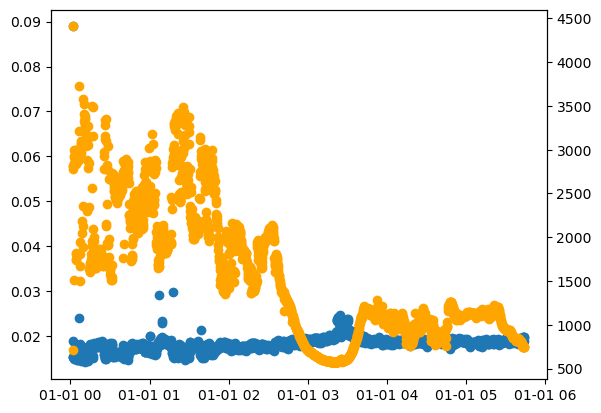

In [34]:
results = []
for row in df.itertuples():
    data = row.data[0]
    if data["sensor"]=="AMBIT_2":
        results.append(row)

dfamb = pd.DataFrame(results)
inner = pd.json_normalize(dfamb['data'].str[0])   # -> data.battery_v, sensor, measure_id, ...
inner.index = dfamb.index
dfamb = pd.concat([dfamb.drop(columns='data'), inner], axis=1)
dfamb.head()

dfamb = dfamb[dfamb["data.s_fluo"].str.len() == 4]
dfamb["processed_timestamp"] = pd.to_datetime(dfamb["processed_timestamp"])
dfamb["measurement_time_utc"] = pd.to_datetime(dfamb["measurement_time_utc"])
dfamb = dfamb[dfamb["processed_timestamp"] > "2026-06-09 13:00:00"]

dfamb["fluo_ss"] = [np.mean(np.array(x)/np.array(y)) for x, y in zip(dfamb["data.s_fluo"],dfamb["data.r_fluo"])]
dfamb["sun"] = [np.mean(np.array(x)) for x in dfamb["data.sun"]]


fig, ax = plt.subplots()
ax.scatter(dfamb["measurement_time_utc"], dfamb["fluo_ss"], label="s_fluo_0")
ax2 = ax.twinx()
ax2.scatter(dfamb["measurement_time_utc"], dfamb["sun"], label="sun", color="orange")


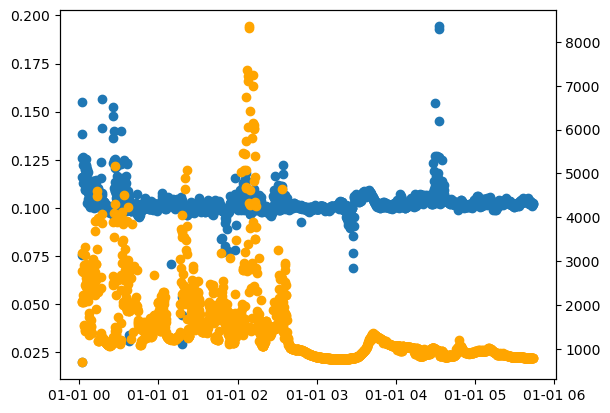

In [35]:
results = []
for row in df.itertuples():
    data = row.data[0]
    if data["sensor"]=="AMBIT_3":
        results.append(row)

dfamb = pd.DataFrame(results)
inner = pd.json_normalize(dfamb['data'].str[0])   # -> data.battery_v, sensor, measure_id, ...
inner.index = dfamb.index
dfamb = pd.concat([dfamb.drop(columns='data'), inner], axis=1)
dfamb.head()

dfamb = dfamb[dfamb["data.s_fluo"].str.len() == 4]
dfamb["processed_timestamp"] = pd.to_datetime(dfamb["processed_timestamp"])
dfamb["measurement_time_utc"] = pd.to_datetime(dfamb["measurement_time_utc"])
dfamb = dfamb[dfamb["processed_timestamp"] > "2026-06-09 13:00:00"]

dfamb["fluo_ss"] = [np.mean(np.array(x)/np.array(y)) for x, y in zip(dfamb["data.s_fluo"],dfamb["data.r_fluo"])]
dfamb["sun"] = [np.mean(np.array(x)) for x in dfamb["data.sun"]]


fig, ax = plt.subplots()
ax.scatter(dfamb["measurement_time_utc"], dfamb["fluo_ss"], label="s_fluo_0")
ax2 = ax.twinx()
ax2.scatter(dfamb["measurement_time_utc"], dfamb["sun"], label="sun", color="orange")


In [ ]:
results = []
for row in df.itertuples():
    data = row.data[0]
    if data["sensor"]=="AMBIT_4":
        results.append(row)

dfamb = pd.DataFrame(results)
inner = pd.json_normalize(dfamb['data'].str[0])   # -> data.battery_v, sensor, measure_id, ...
inner.index = dfamb.index
dfamb = pd.concat([dfamb.drop(columns='data'), inner], axis=1)
dfamb.head()

dfamb = dfamb[dfamb["data.s_fluo"].str.len() == 4]
dfamb["processed_timestamp"] = pd.to_datetime(dfamb["processed_timestamp"])
dfamb["measurement_time_utc"] = pd.to_datetime(dfamb["measurement_time_utc"])
dfamb = dfamb[dfamb["processed_timestamp"] > "2026-06-09 13:00:00"]

dfamb["fluo_ss"] = [np.mean(np.array(x)/np.array(y)) for x, y in zip(dfamb["data.s_fluo"],dfamb["data.r_fluo"])]
dfamb["sun"] = [np.mean(np.array(x)) for x in dfamb["data.sun"]]


fig, ax = plt.subplots()
ax.scatter(dfamb["measurement_time_utc"], dfamb["fluo_ss"], label="s_fluo_0")
ax2 = ax.twinx()
ax2.scatter(dfamb["measurement_time_utc"], dfamb["sun"], label="sun", color="orange")
